# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [55]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [57]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O dataset é uma base de dados para treinamento de aprendizado supervisionado, possuindo 60.000 imagens coloridas de 32x32 em 10 classes, com 6.000 imagens por classe. Existem 50.000 imagens de treinamento e 10.000 imagens de teste. Ele é dividido em 10 classes, sendo elas avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio e caminhão.

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [58]:
print(f'Conjunto de treino: y: {y_train.shape}, x: {x_train.shape}')
print(f'Conjunto de validação: y: {y_val.shape}, x: {x_val.shape}')
print(f'Conjunto de teste: y: {y_test.shape}, x: {x_test.shape}')
print(f'Valores únicos: {np.unique(y_train)}')

Conjunto de treino: y: (40000,), x: (40000, 32, 32, 3)
Conjunto de validação: y: (10000,), x: (10000, 32, 32, 3)
Conjunto de teste: y: (10000,), x: (10000, 32, 32, 3)
Valores únicos: [0 1 2 3 4 5 6 7 8 9]


Dado as saídas, há 40 mil imagens no conjunto de treino, 10 mil na validação e 10 mil no conjunto teste. Todas possuem resolução 32x32, 3 canais e 10 classes diferentes no dataset.

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

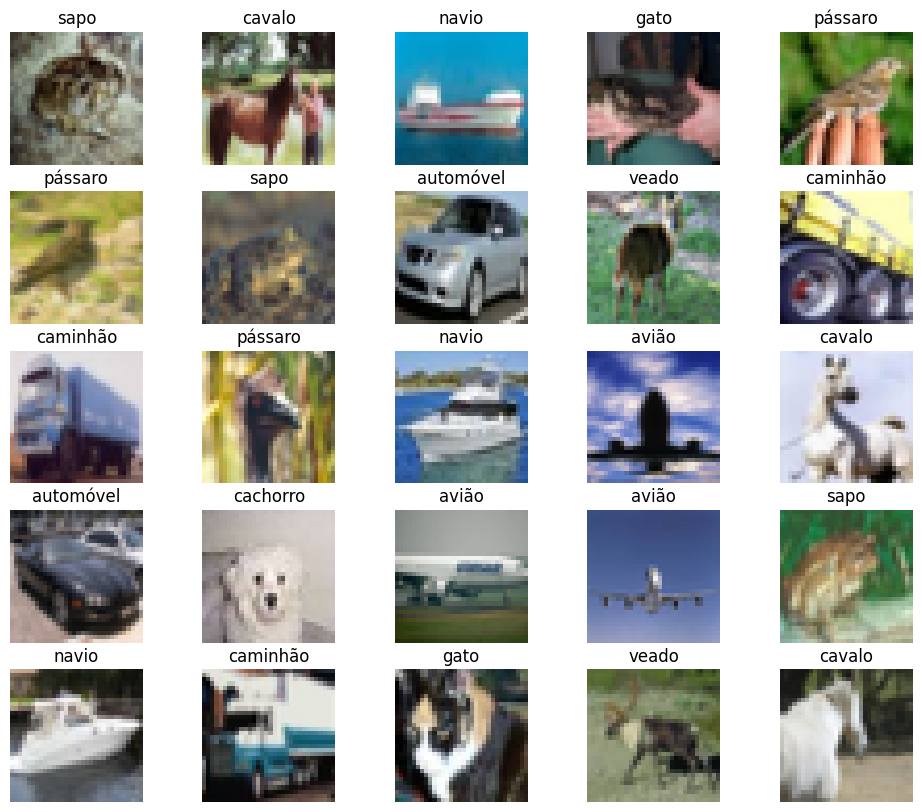

In [59]:
classes = ['avião', 'automóvel', 'pássaro', 'gato', 'veado',
           'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']
# A ordem das classes está na documentação (https://www.cs.toronto.edu/~kriz/cifar.html)
plt.figure(figsize=(12,10))
for i in range(25):
  plt.subplot(5,5,i+1,)
  plt.axis('off')
  plt.title(classes[y_train[i]])
  plt.imshow(x_train[i],)

Dado as imagens, apesar de serem excludentes entre si, o que deveria facilitar a classificação, a qualidade das imagens peca, o que dificulta a classificação. Além disso, há classes que podem ser confundidas entre si, como Veado e Cavalo e Sapo e Pássaro.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

<BarContainer object of 10 artists>

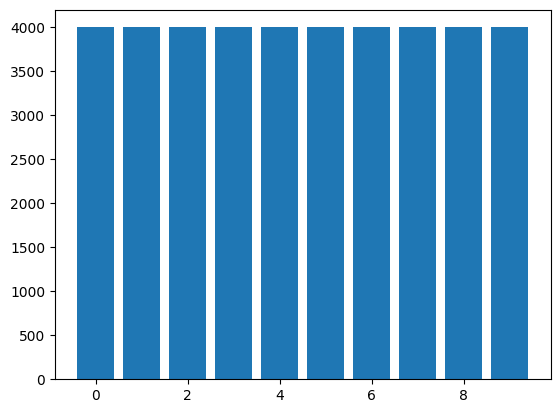

In [60]:
bar_plot = np.unique(y_train, return_counts=True)
plt.bar(x = bar_plot[0], height=bar_plot[1])

Dado os valores apresentados pelo gráfico, o dataset é perfeitamente balanceado, sendo que cada classe possui 1/10 do dataset. O dataset ser balanceado impacta positivamente no modelo, já que caso ele fosse desbalanceado ele poderia ficar propenso a classificar classes minoritárias como parte de classes majoritárias.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [61]:
print("Antes de normalizar:")
print(f'Valor mínimo: {x_train.min()}')
print(f'Valor máximo: {x_train.max()}')
x_train = x_train/255
x_val = x_val/255
x_test = x_test/255
print("\nDepois de normalizar")
print(f'Valor mínimo: {x_train.min()}')
print(f'Valor máximo: {x_train.max()}')

Antes de normalizar:
Valor mínimo: 0
Valor máximo: 255

Depois de normalizar
Valor mínimo: 0.0
Valor máximo: 1.0


Dado que os dados envolvem imagens, a normalização dos valores faz com que a magnitude do gradiente seja menor, o que auxilia na estabilização e acelera a convergência, uma vez que o gradiente maior pode fazer com que o gradiente divirja, dado a diferença do intervalo.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

Elas podem ser representadas como tensores tridimensionais dada a natureza de imagens RGB, uma vez que as dimensões representam o tamanho da imagem(32x32) e a quantidade de canais que as imagens possuem(3), portanto, elas possuem 32x32 pixels e os 3 canais do RGB. Dito isso, imagens em tons de cinza possuem apenas 1 canal, podendo, então, ser representados como 2D e não 3D como imagens com mais de 1 canal. Isso afeta a quantidade de informações que o modelo precisará analisar e a quantidade de parâmetros que ele precisará ajustar na camada de entrada da rede.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

É necessário transformar as imagens porque as MLPs entendem apenas os valores dos vetores, logo, devem ser transformadas antes de passar para a MLP. A estrutura espacial das imagens é transformada em um vetor com 3072(32x32x3) valores, o que faz com que a informação sobre a relação entre pixels seja perdida para que o vetor de valores possa passar para a MLP.

In [62]:
tf.keras.backend.clear_session()

model_mlp = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(32,32,3), name='Entrada_Flatten'),
        tf.keras.layers.Dense(512, activation='relu', name='Dense1'),
        tf.keras.layers.Dense(256, activation='relu', name='Dense2'),
        tf.keras.layers.Dense(10, activation='softmax', name='Saida_Softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [63]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Flatten (Flatten)       │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Softmax (Dense)           │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

As MLPs podem se tornar modelos muito grandes para problemas de classificação de imagens dado a natureza das imagens. Como discutido anteriormente, as imagens RGB se tornam grandes pela natureza dos 3 canais(RGB) e mais as dimensões da imagem, o que faz com que ele tenha que ter as dimensões da imagem(32x32) vezes os canais(3) na camada de entrada. As camadas densas, dado que cada neurônio se interconectam e ainda possuem mais um Bias de cada neurônio, fazem com que o problema cresça rapidamente.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [64]:
model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

O papel da função de custo nesse cenário é penalizar fortemente o modelo quando ele errar com confiança e nesse cenário, a função de custo é perfeita para esse cenário visto que ela é usado quando possuimos categorias diferentes e elas são representadas por índices inteiros das classes. O Softmax é perfeito para esse cenário pois ele vai dar na saída as probabilidades de uma amostra pertencer a cada uma das classes. O objetivo do otimizador Adam, que é uma variação do gradiente descendente, é adaptar a taxa de aprendizado para cada parâmetro individualmente, atualizando os pesos da rede e corrigindo os erros apontados pela função de custo.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

In [65]:
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs = 25,
    validation_data=(x_val, y_val)
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.3196 - loss: 1.8755 - val_accuracy: 0.3532 - val_loss: 1.7887
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.3922 - loss: 1.6922 - val_accuracy: 0.4023 - val_loss: 1.6655
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 35ms/step - accuracy: 0.4207 - loss: 1.6073 - val_accuracy: 0.4203 - val_loss: 1.6211
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.4419 - loss: 1.5524 - val_accuracy: 0.4344 - val_loss: 1.5913
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 30ms/step - accuracy: 0.4581 - loss: 1.5126 - val_accuracy: 0.4508 - val_loss: 1.5651
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.4692 - loss: 1.4812 - val_accuracy: 0.4636 - val_loss: 1.5379
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.4795 - loss: 1.4522 - val_accuracy: 0.4639 - val_loss: 1.5404
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.4885 -

Text(0.5, 1.0, 'Loss nos conjuntos para a MLP')

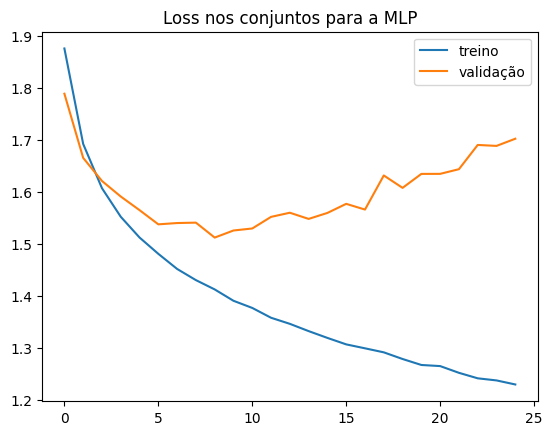

In [66]:
plt.plot(history_mlp.history['loss'], label='treino')
plt.plot(history_mlp.history['val_loss'], label = 'validação')
plt.legend()
plt.title('Loss nos conjuntos para a MLP')

Text(0.5, 1.0, 'Accuracy nos conjuntos para a MLP')

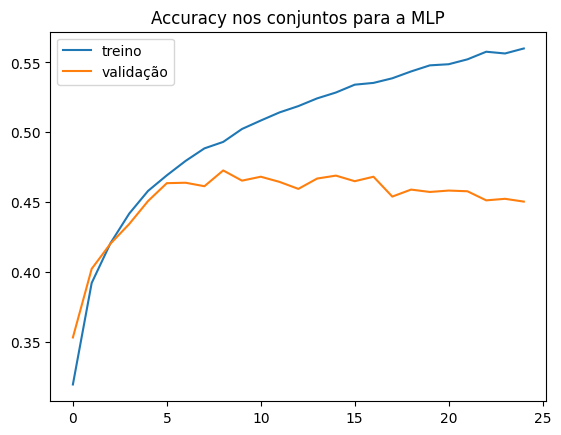

In [67]:
plt.plot(history_mlp.history['accuracy'], label='treino')
plt.plot(history_mlp.history['val_accuracy'], label = 'validação')
plt.legend()
plt.title('Accuracy nos conjuntos para a MLP')

O modelo não converge tão adequadamente e analisando ambos os gráficos, a partir da 8ª época o conjunto de treino continua melhorando tanto em loss quanto em accuracy mas o conjunto de validação estabiliza, tendo algumas leves flutuações mas estável no geral, o que indica overfitting por treino em melhora mas validação com problemas em generalizar.

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [68]:
model_mlp.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4535 - loss: 1.6626


[1.6626001596450806, 0.45350000262260437]

Comparando com a última época, o modelo se mostra consistente com dados que nunca viu, visto os dados de validação e teste, porém a diferença entre os conjuntos de treino e teste indicam que o modelo não possui uma capacidade tão boa de generalizar.

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

In [69]:
!pip install pandas

In [70]:
import pandas as pd

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


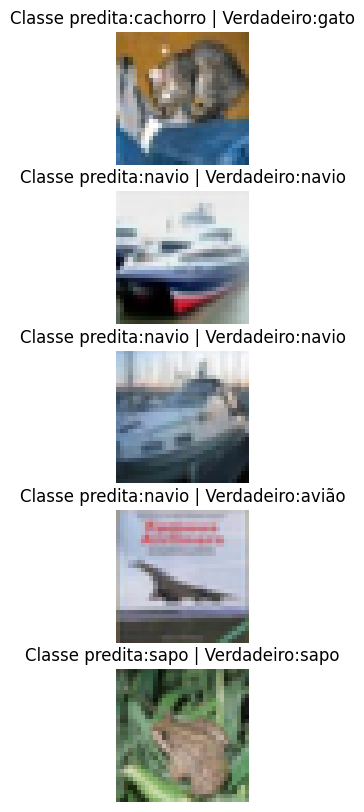

In [71]:
predicao = model_mlp.predict(x_test[:5])
classes_predicao = np.argmax(predicao, axis=1)
plt.figure(figsize=(12,10))
for i in range(5):
  plt.subplot(5,1,i+1,)
  plt.axis('off')
  plt.title(f'Classe predita:{classes[classes_predicao[i]]} | Verdadeiro:{classes[y_test[i]]}')
  plt.imshow(x_test[i])

In [72]:
print(f'Probabilidades: ')
pd.DataFrame(predicao, columns=class_names)

Probabilidades: 


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,0.033775,0.003175,0.006262,0.290452,0.011837,0.605211,0.003746,0.011190,0.021214,0.013139
1,0.012957,0.311069,0.000393,0.000004,0.001355,0.000003,0.000006,0.000191,0.544314,0.129708
2,0.295490,0.021283,0.006243,0.000577,0.006528,0.001043,0.000291,0.001673,0.574674,0.092197
3,0.215511,0.003497,0.138588,0.021425,0.018285,0.005732,0.001357,0.047850,0.506840,0.040915
4,0.000536,0.000161,0.079269,0.010716,0.443858,0.004070,0.459674,0.001167,0.000393,0.000156


A saída de um softmax é a probabilidade de a amostra pertencer a cada uma das classes. Dito isso, o modelo não está prevendo com alta confiança dado que as probabilidades no geral estão bem distribuídas entre as classes, sendo que a classe que ele diz ser é a maior mas não alta o suficiente para dizer que ele diz com certeza. Vale a pena destacar o caso da 5ª amostra, onde ele fala com alta confiança(91% de certeza) que é uma classe(veado) quando na verdade não é(era sapo), o que seria penalizado pela entropia cruzada caso ele tivesse continuado sendo treinado.

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


<Axes: >

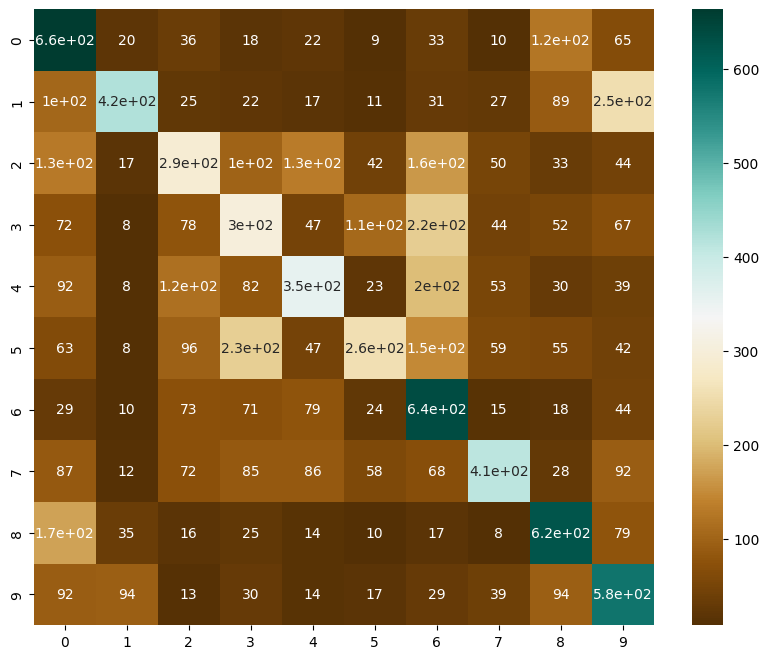

In [73]:
predicao = np.argmax(model_mlp.predict(x_test), axis=1)
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, predicao),cmap='BrBG', annot=True)

As principais confusões do modelo foram: navio classificado como avião, caminhão classificado como automóvel, gato classificado como pássaro, veado classificado como pássaro, cachorro classificado como gato e cavalo classificado como veado. Esses erros fazem sentido considerando a proximidade visual entre as classes. Além disso, o Flatten das imagens antes de passar para a MLP fez com que a relação entre os pixels fosse perdida, que era a informação que poderia distinguir as classes visualmente próximas entre si.

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

As MLPs são simples de treinar e entender o que está acontecendo, mas no geral não são boas para classificação de imagens, visto a quantidade de parâmetros que tem que ser treinados, a perda da relação entre pixels vizinhos, a baixa capacidade de generalização e baixo desempenho obtido.

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

As MLPs possuem a camada Flatten que faz com que a relação entre os pixels se perca, o que é a maior limitação de MLPs em problemas de visão computacional. As CNNs não, elas dividem pequenas partes da imagem em kernels, que são regiões da imagem, e cada padrão identificado pelo kernel pode estar em diferentes localidades da imagem pelo princípio de estacionaridade, o que reduz o número de parâmetros a serem treinados, reduz o risco de overfitting e não há necessidade de aprender o mesmo padrão mais de uma vez. A convolução que a CNN aplica é para extrair características das imagens, ela faz isso passando o filtro convolucional, que possui pesos, pela imagem e somando o resultado das multiplicações para resultar em saídas escalares e a matriz final gerada por essa operação é chamado de feature map.

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [74]:
tf.keras.backend.clear_session()

model_cnn = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(32, activation='relu', kernel_size=(3,3), input_shape=(32,32,3), name='Convolucao1'),
        tf.keras.layers.MaxPool2D(name='Pooling1'),
        tf.keras.layers.Conv2D(64, activation='relu', kernel_size=(3,3), name='Convolucao2'),
        tf.keras.layers.MaxPool2D(name='Pooling2'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu', name='Dense1'),
        tf.keras.layers.Dense(256, activation='relu', name='Dense2'),
        tf.keras.layers.Dense(10, activation='softmax', name='Saida_Softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


As camadas convolucionais são responsáveis por extrair as características das imagens através do filtro de convolução, as camadas de Pooling são responsáveis por reduzir o tamanho da matriz gerada pelos resultados das convoluções e a camada de Flatten é responsável por deixar tudo em um único vetor para ser passado pelas camadas densas da MLP.

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [75]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolucao1 (Conv2D)            │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling1 (MaxPooling2D)         │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolucao2 (Conv2D)            │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling2 (MaxPooling2D)         │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Softmax (Dense)           │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,450 (5.09 MB)

 Trainable params: 1,333,450 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

A MLP possuía 1.707.274 parâmetros treináveis, enquanto a CNN possui 1.333.450 parâmetros treináveis, dos quais a maior parte fica nas camadas densas, que são parte da MLP, não da CNN. As CNNs costumam ser melhores para visão computacional devido a convolução e ao Pooling que faz com que a informação entre os pixels não seja perdida antes de passar pelo Flatten.

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

In [76]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs = 25,
    validation_data=(x_val, y_val)
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 97s 73ms/step - accuracy: 0.4684 - loss: 1.4559 - val_accuracy: 0.5885 - val_loss: 1.1572
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 132s 64ms/step - accuracy: 0.6216 - loss: 1.0650 - val_accuracy: 0.6463 - val_loss: 1.0106
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6921 - loss: 0.8756 - val_accuracy: 0.6676 - val_loss: 0.9852
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 63ms/step - accuracy: 0.7495 - loss: 0.7200 - val_accuracy: 0.6692 - val_loss: 1.0436
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 63ms/step - accuracy: 0.7989 - loss: 0.5826 - val_accuracy: 0.6579 - val_loss: 1.1487
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - accuracy: 0.8363 - loss: 0.4714 - val_accuracy: 0.6531 - val_loss: 1.2834
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 72ms/step - accuracy: 0.8699 - loss: 0.3676 - val_accuracy: 0.6508 - val_loss: 1.4609
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.8968 

Text(0.5, 1.0, 'Loss nos conjuntos para a CNN')

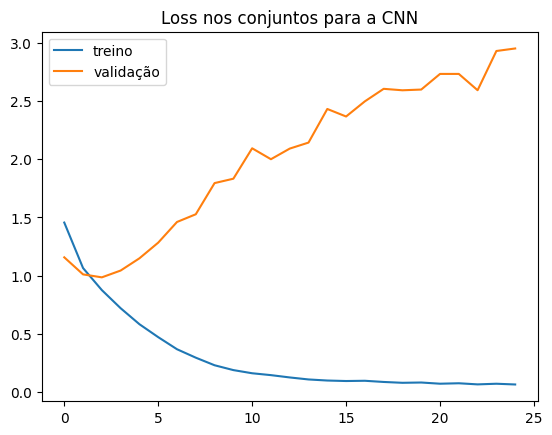

In [77]:
plt.plot(history_cnn.history['loss'], label='treino')
plt.plot(history_cnn.history['val_loss'], label = 'validação')
plt.legend()
plt.title('Loss nos conjuntos para a CNN')

Text(0.5, 1.0, 'Accuracy nos conjuntos para a CNN')

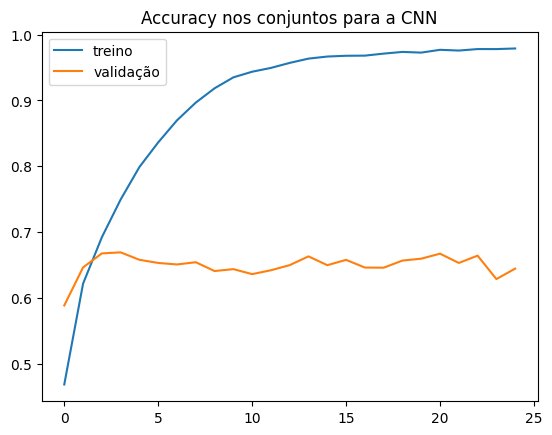

In [78]:
plt.plot(history_cnn.history['accuracy'], label='treino')
plt.plot(history_cnn.history['val_accuracy'], label = 'validação')
plt.legend()
plt.title('Accuracy nos conjuntos para a CNN')

De acordo com os gráficos plotados e as métricas exibidas, a CNN apresenta sinais claros de overfitting, com um conjunto de treino com acurácia extremamente alta e o conjunto de validação com acurácia bem mais baixa. Vale falar sobre a época 5, que era o melhor cenário possível de todas as épocas até então, onde o overfitting estava bem mais controlado e a acurácia do conjunto de validação estava bem mais alto, onde poderia ter sido feito um early stopping.

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [79]:
model_cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6420 - loss: 3.0048


[3.004793643951416, 0.6420000195503235]

A MLP conseguiu uma acurácia por volta de 47%, enquanto a CNN conseguiu uma acurácia por volta de 63%, o que mostra como a CNN é melhor que a MLP para visão computacional. Isso era o esperado dado a diferença fundamental da CNN e da MLP, onde a primeira conserva a relação entre os pixels enquanto a segunda descarta. Dito isso, a CNN conseguiu generalizar melhor que a MLP, mas dado o overfitting severo que ela apresentou, um early stopping poderia ter aumentado ainda mais a acurácia do modelo.

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


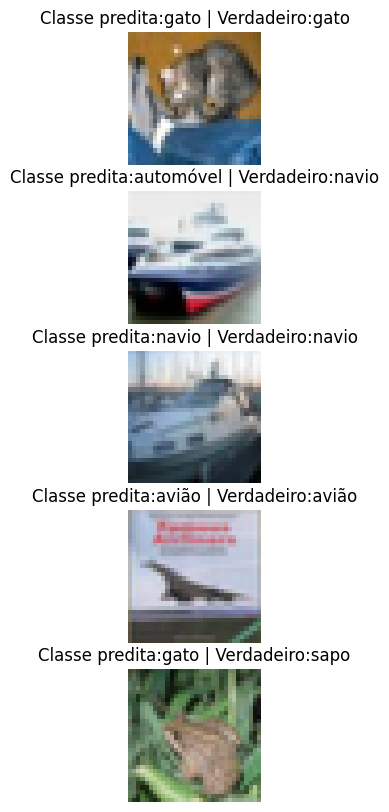

In [80]:
predicao_cnn = model_cnn.predict(x_test[:5])
classes_predicao = np.argmax(predicao_cnn, axis=1)
plt.figure(figsize=(12,10))
for i in range(5):
  plt.subplot(5,1,i+1,)
  plt.axis('off')
  plt.title(f'Classe predita:{classes[classes_predicao[i]]} | Verdadeiro:{classes[y_test[i]]}')
  plt.imshow(x_test[i])

In [81]:
print(f'Probabilidades: ')
pd.DataFrame(predicao_cnn, columns=class_names)

Probabilidades: 


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,1.107061e-11,9.731975e-07,2.060520e-08,9.999973e-01,3.436490e-11,1.616249e-06,5.047824e-10,4.828181e-11,1.211149e-07,2.742652e-12
1,6.602795e-03,9.736444e-01,4.056245e-24,1.306760e-19,6.909388e-24,1.929331e-25,1.237329e-19,2.627511e-27,1.975269e-02,2.189951e-12
2,1.898484e-02,3.894479e-01,3.399389e-11,1.737959e-06,4.485649e-09,5.919431e-09,1.341634e-09,1.887509e-09,5.891992e-01,2.366172e-03
3,9.999518e-01,5.825531e-12,5.067453e-08,2.437791e-14,1.951099e-13,1.303502e-14,6.697443e-14,5.521964e-16,4.812678e-05,2.293201e-10
4,7.422162e-11,1.224537e-09,2.328120e-05,9.318175e-01,6.501291e-02,1.551267e-03,1.595014e-03,1.938212e-10,1.449896e-08,1.302926e-09


A CNN possui confiança muito maior que a MLP quando vai fazer suas predições, sendo que as probabilidades estão mais concentradas na classe que ele diz ser, tanto quando erra quanto quando ele acerta. Isso se deve a diferença entre ambos em que a CNN entende as relações entre os pixels e consegue extrair características espaciais mais ricas e discriminativas, enquanto a MLP apenas descarta a relação.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


<Axes: >

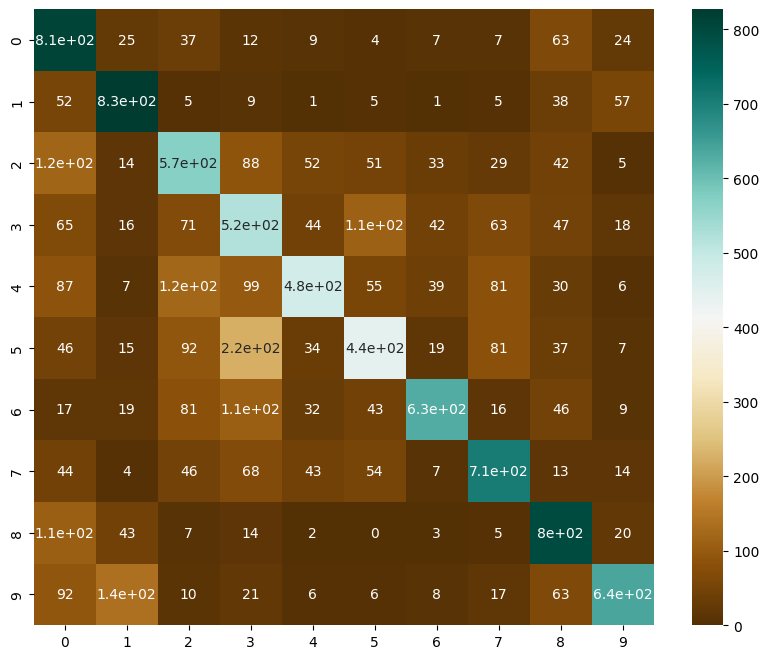

In [82]:
predicao_cnn = np.argmax(model_cnn.predict(x_test), axis=1)
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, predicao_cnn),cmap='BrBG', annot=True)

A diagonal principal apresentou uma melhora significante em relação a MLP, além da confusão geral que diminui bem mais quando comparado a MLP. As classes que ainda possuem confusão são muito semelhantes entre si, caminhão e automóvel, cachorro e gato e cavalo e veado. A confusão entre as classes semelhantes visualmente é atenuada pela CNN pela relação entre os kernels, mas ainda há confusão devido a essa semelhança.

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

In [83]:
tf.keras.backend.clear_session()

model_cnn_dropout = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(32, activation='relu', kernel_size=(3,3), input_shape=(32,32,3), name='Convolucao1'),
        tf.keras.layers.MaxPool2D(name='Pooling1'),
        tf.keras.layers.Conv2D(64, activation='relu', kernel_size=(3,3), name='Convolucao2'),
        tf.keras.layers.MaxPool2D(name='Pooling2'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu', name='Dense1'),
        tf.keras.layers.Dropout(rate = 0.25, name='Dropout1'),
        tf.keras.layers.Dense(256, activation='relu', name='Dense2'),
        tf.keras.layers.Dropout(0.25, name='Dropout2'),
        tf.keras.layers.Dense(10, activation='softmax', name='Saida_Softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model_cnn_dropout.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolucao1 (Conv2D)            │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling1 (MaxPooling2D)         │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolucao2 (Conv2D)            │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling2 (MaxPooling2D)         │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Softmax (Dense)           │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,450 (5.09 MB)

 Trainable params: 1,333,450 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model_cnn_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

history_cnn_dropout = model_cnn_dropout.fit(
    x_train, y_train,
    epochs = 25,
    validation_data=(x_val, y_val)
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.4475 - loss: 1.5090 - val_accuracy: 0.5976 - val_loss: 1.1492
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.6037 - loss: 1.1233 - val_accuracy: 0.6410 - val_loss: 1.0380
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - accuracy: 0.6683 - loss: 0.9514 - val_accuracy: 0.6667 - val_loss: 0.9696
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.7192 - loss: 0.8099 - val_accuracy: 0.6678 - val_loss: 0.9852
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.7551 - loss: 0.7015 - val_accuracy: 0.6704 - val_loss: 0.9995
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 66ms/step - accuracy: 0.7900 - loss: 0.5990 - val_accuracy: 0.6659 - val_loss: 1.0451
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.8153 - loss: 0.5198 - val_accuracy: 0.6663 - val_loss: 1.1148
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.8431 

Text(0.5, 1.0, 'Loss nos conjuntos para a CNN com Dropout')

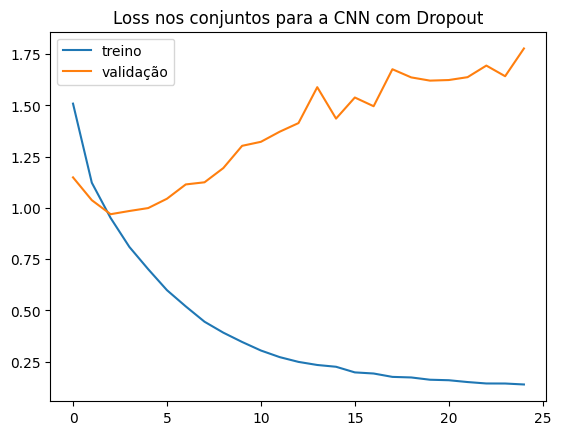

In [86]:
plt.plot(history_cnn_dropout.history['loss'], label='treino')
plt.plot(history_cnn_dropout.history['val_loss'], label = 'validação')
plt.legend()
plt.title('Loss nos conjuntos para a CNN com Dropout')

Text(0.5, 1.0, 'Accuracy nos conjuntos para a CNN com Dropout')

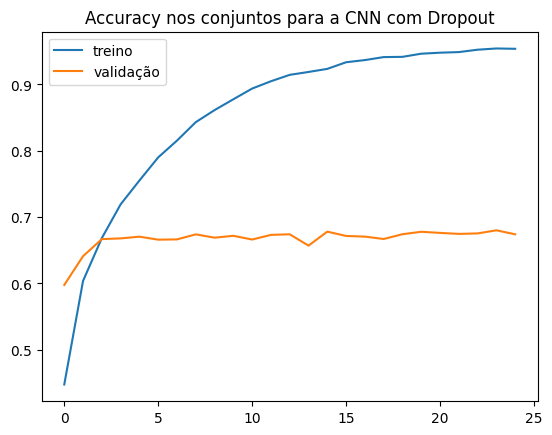

In [87]:
plt.plot(history_cnn_dropout.history['accuracy'], label='treino')
plt.plot(history_cnn_dropout.history['val_accuracy'], label = 'validação')
plt.legend()
plt.title('Accuracy nos conjuntos para a CNN com Dropout')

Baseado nos valores dado pela CNN com dropout na 25ª época, o modelo conseguiu reduzir o overfitting e melhorar sua capacidade de generalização no final. Ele ainda continua em overfitting, porém ele está mais controlado do que quando ele não tinha dropout, com uma diferença de 69% de acurácia no conjunto de validação no modelo com dropout e 63% no mesmo conjunto sem dropout. Além disso, o treino caiu de 97% de acurácia para 95%, diminuindo o overfitting.

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

Baseado em todos os resultados obtidos ao longo da atividade e na própria natureza de ambos os modelos, a conclusão que se chega é que a MLP é melhor que a CNN para visão computacional apenas inicialmente por ser um pouco mais simples de se entender e mais simples de se implementar, porém peca em todos os outros aspectos. A CNN, mesmo que mais demorada, possui menos parâmetros a serem ajustados, possui uma acurácia maior e uma capacidade de generalização maior que a MLP e isso se dá principalmente devido a natureza de ambos, já que a MLP ignora o contexto das informações dos pixels vizinhos enquanto a CNN tenta extrair o máximo de informação possível, o que faz com que a CNN além de possuir uma acurácia maior ainda consegue afirmar sua conclusão com maior confiança que a MLP, já que ele entende as características gerais antes de passar pela camada Flatten. Em resumo, para problemas de visão computacional, o modelo a ser usado é a CNN.